# IPL Data Analytics Project 

Built using matches.csv and deliveries.csv.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print(matches.shape)
print(deliveries.shape)


(756, 18)
(179078, 21)


## Dataset Overview

In [2]:
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [3]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


## Missing Values

In [4]:
matches.isnull().sum().sort_values(ascending=False)

umpire3            637
city                 7
winner               4
player_of_match      4
umpire1              2
umpire2              2
season               0
id                   0
team1                0
date                 0
dl_applied           0
result               0
toss_decision        0
toss_winner          0
team2                0
win_by_runs          0
win_by_wickets       0
venue                0
dtype: int64

## Most Successful Teams

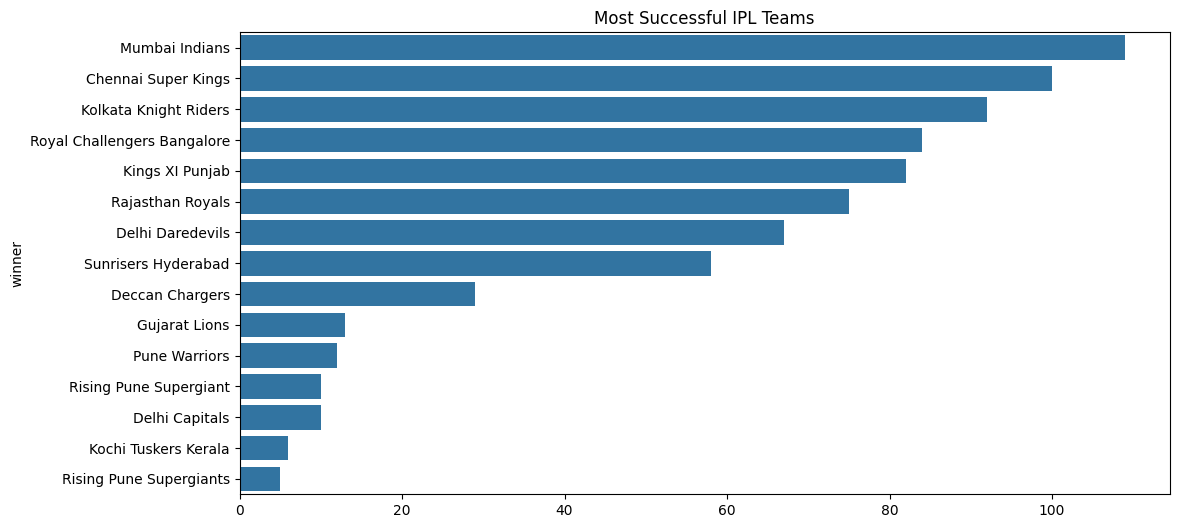

In [5]:
wins = matches['winner'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=wins.values,y=wins.index)
plt.title('Most Successful IPL Teams')
plt.show()


## Toss Winner vs Match Winner

In [6]:
matches['toss_match_win']=(matches['toss_winner']==matches['winner'])
matches['toss_match_win'].value_counts(normalize=True)*100


toss_match_win
True     51.984127
False    48.015873
Name: proportion, dtype: float64

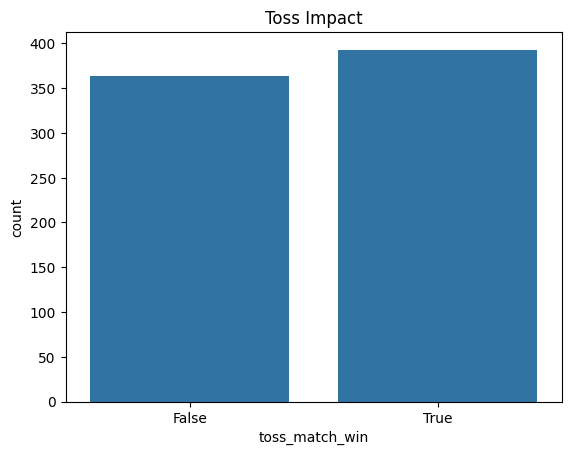

In [7]:
sns.countplot(x='toss_match_win',data=matches)
plt.title('Toss Impact')
plt.show()


## Toss Decisions

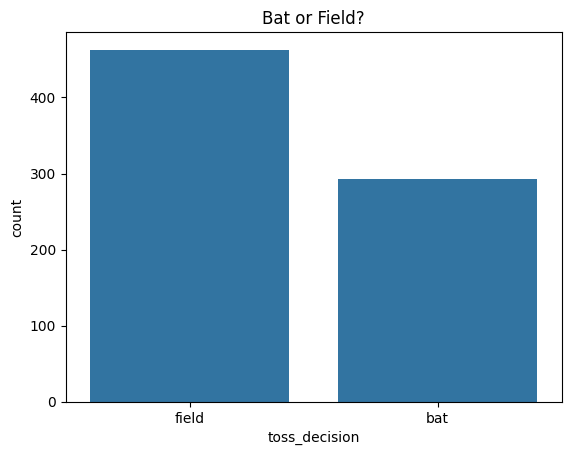

In [8]:
sns.countplot(x='toss_decision',data=matches)
plt.title('Bat or Field?')
plt.show()


## Top Venues

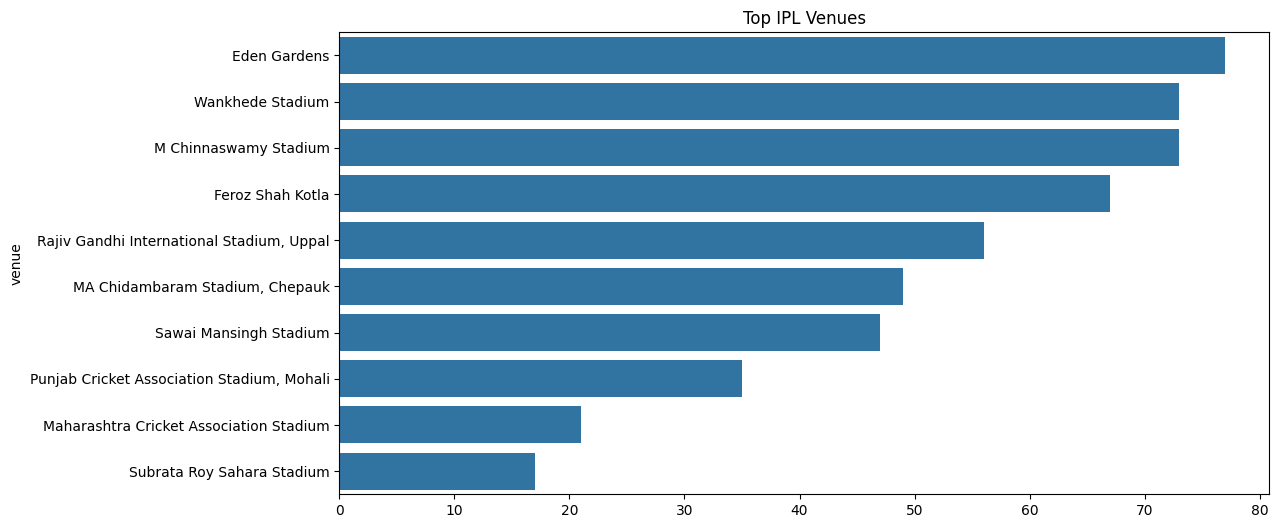

In [9]:
top_venues=matches['venue'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_venues.values,y=top_venues.index)
plt.title('Top IPL Venues')
plt.show()


## Matches Per Season

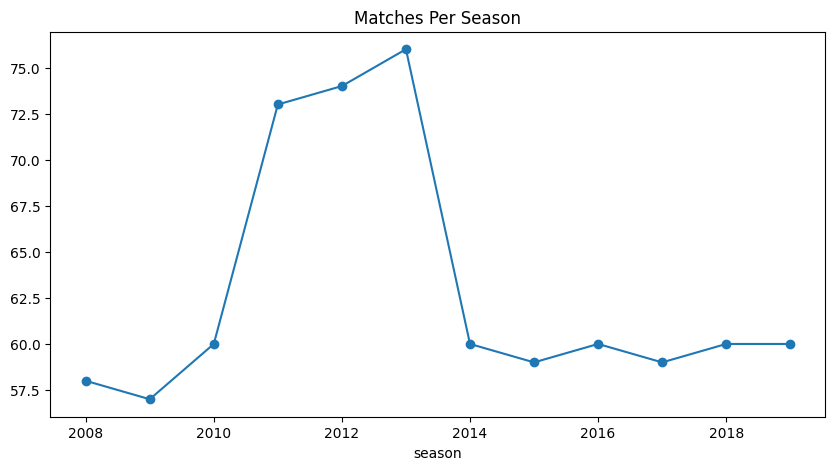

In [10]:
season_matches=matches.groupby('season').size()

plt.figure(figsize=(10,5))
season_matches.plot(marker='o')
plt.title('Matches Per Season')
plt.show()


## Orange Cap Analysis

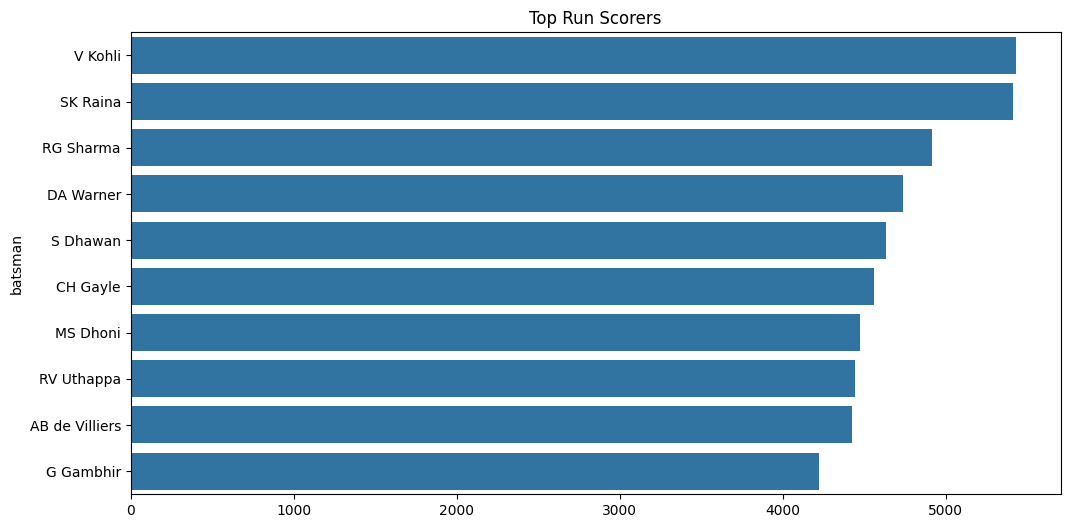

In [11]:
top_runs=deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_runs.values,y=top_runs.index)
plt.title('Top Run Scorers')
plt.show()


## Sixes Distribution per Match

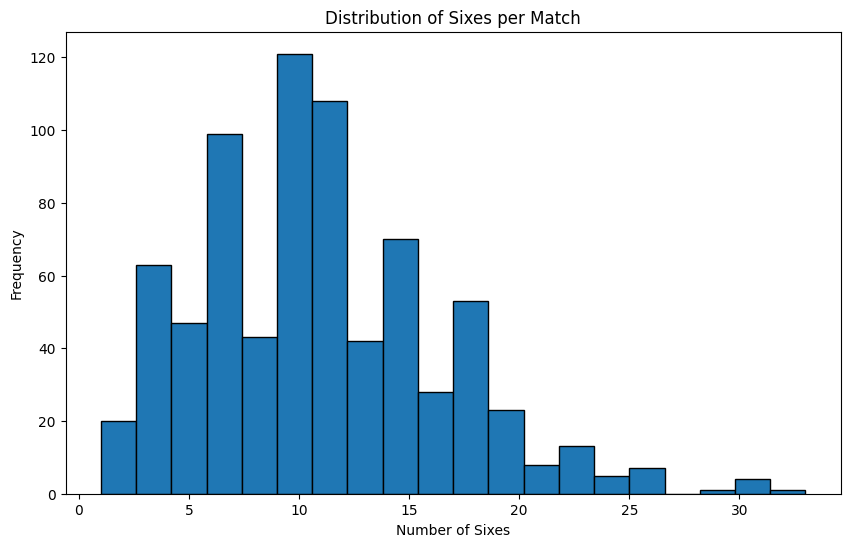

In [22]:
match_sixes = sixes.groupby('match_id').size()

plt.figure(figsize=(10,6))
plt.hist(match_sixes, bins=20, edgecolor='black')

plt.title("Distribution of Sixes per Match")
plt.xlabel("Number of Sixes")
plt.ylabel("Frequency")
plt.show()


## Most Fours

C:\Users\nvs_p\AppData\Local\Temp\ipykernel_39872\3156741558.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_fours.values,y=top_fours.index,palette='magma')


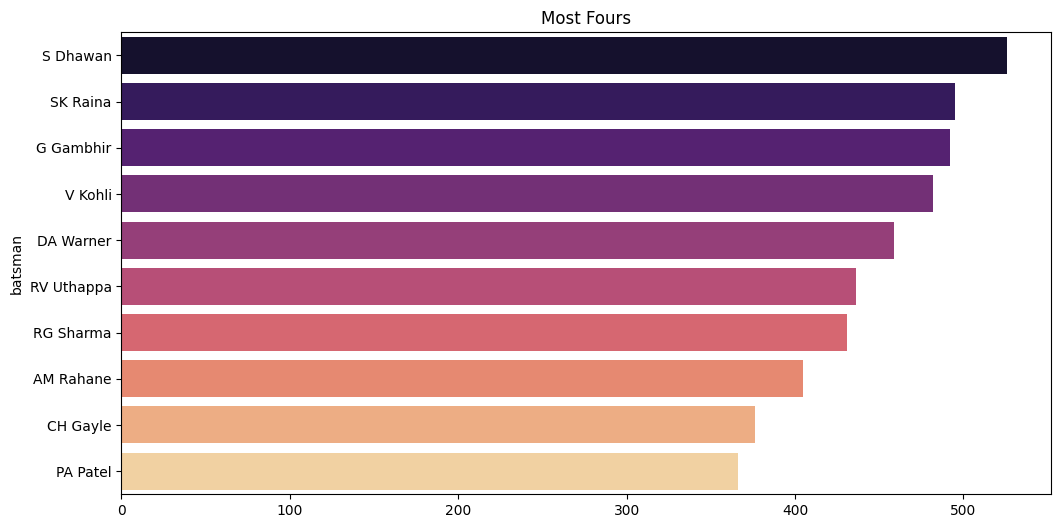

In [24]:
fours=deliveries[deliveries['batsman_runs']==4]
top_fours=fours['batsman'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_fours.values,y=top_fours.index,palette='magma')
plt.title('Most Fours')
plt.show()


## Purple Cap Analysis

C:\Users\nvs_p\AppData\Local\Temp\ipykernel_39872\4237569791.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_wickets.values,y=top_wickets.index,palette='viridis')


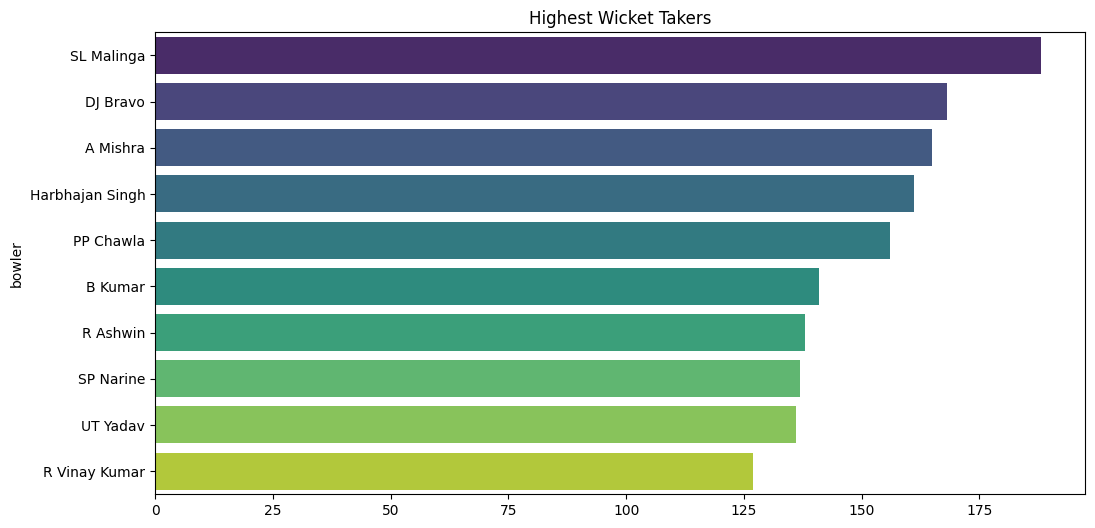

In [23]:
dismissals=deliveries[deliveries['player_dismissed'].notna()]
top_wickets=dismissals.groupby('bowler')['player_dismissed'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_wickets.values,y=top_wickets.index,palette='viridis')
plt.title('Highest Wicket Takers')
plt.show()


## Highest Team Totals

In [15]:
team_scores=deliveries.groupby(['match_id','inning','batting_team'])['total_runs'].sum()
team_scores.sort_values(ascending=False).head(10)


match_id  inning  batting_team               
411       1       Royal Challengers Bangalore    263
7937      1       Kolkata Knight Riders          250
620       1       Royal Challengers Bangalore    248
206       1       Chennai Super Kings            246
11338     1       Kolkata Knight Riders          241
61        1       Chennai Super Kings            240
562       1       Royal Challengers Bangalore    235
11147     1       Sunrisers Hyderabad            233
296       1       Kings XI Punjab                232
11339     1       Sunrisers Hyderabad            232
Name: total_runs, dtype: int64

## Team Dominance Heatmap

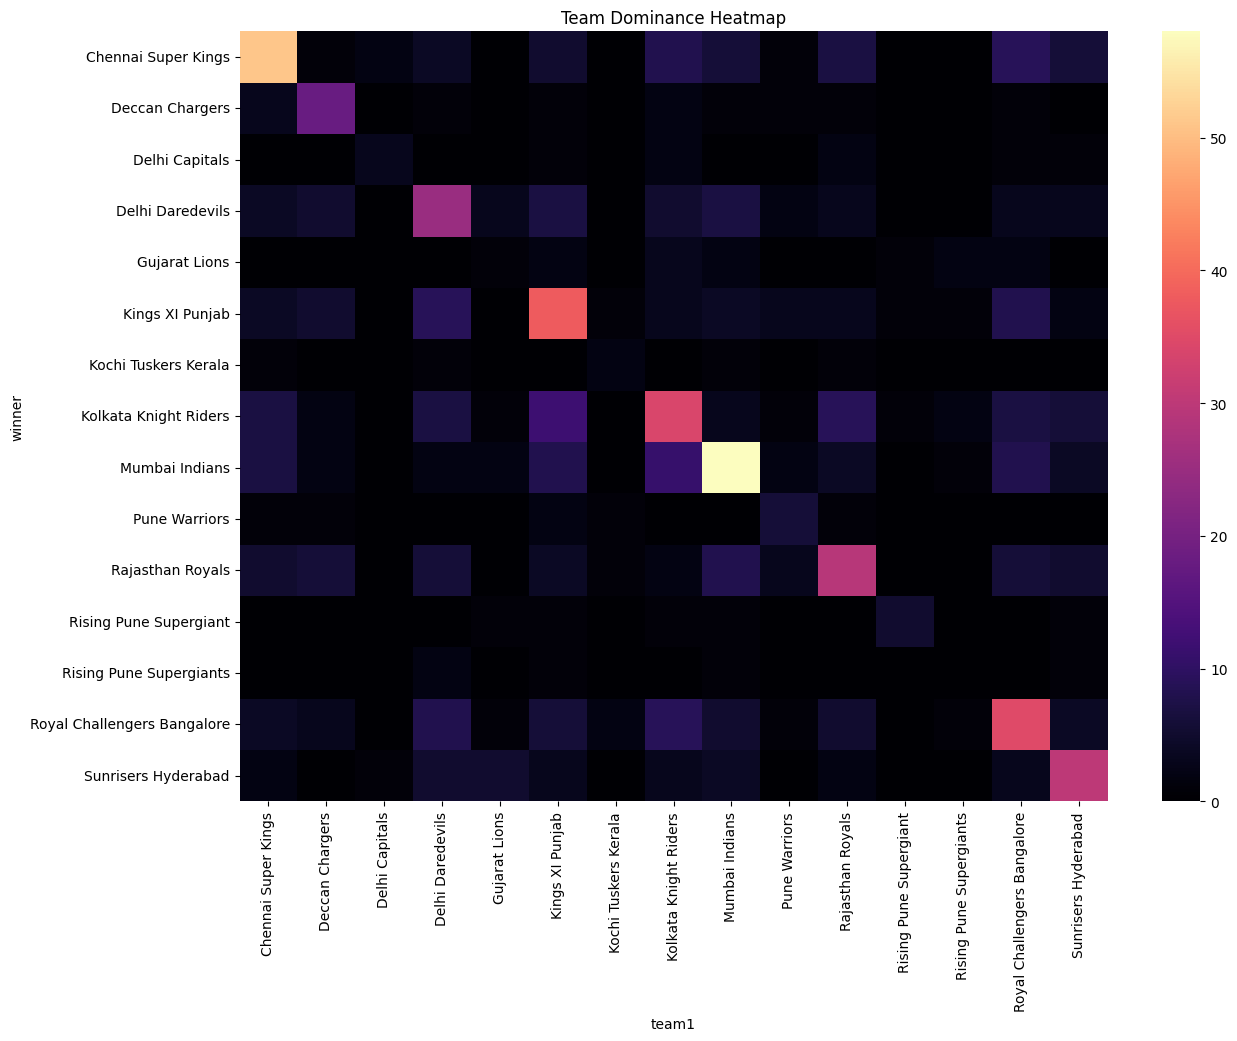

In [16]:
heatmap_data=pd.crosstab(matches['winner'],matches['team1'])

plt.figure(figsize=(14,10))
sns.heatmap(heatmap_data,cmap='magma')
plt.title('Team Dominance Heatmap')
plt.show()


## Player of the Match Leaders

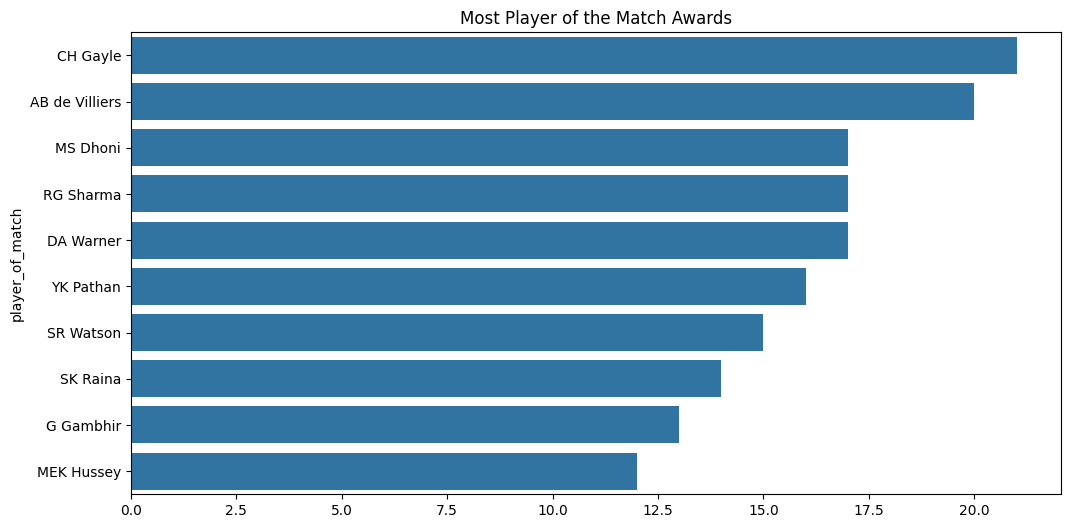

In [17]:
pom=matches['player_of_match'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=pom.values,y=pom.index)
plt.title('Most Player of the Match Awards')
plt.show()


## Key Insights
1. Most successful franchises.
2. Toss impact on outcomes.
3. Venue popularity.
4. Top batsmen and bowlers.
5. Boundary-hitting leaders.
6. Team dominance patterns.